In [2]:
from astroquery.sdss import SDSS
from astroquery.ipac.irsa import Irsa
from astroquery.vizier import Vizier
from astropy import coordinates as coord
from astropy import units as u
from astroquery.ipac.ned import Ned
import numpy as np
import pandas as pd

In [3]:
# Coordenadas de ejemplo
ra, dec = 1.7376141,0.8571812 # en grados
pos = coord.SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')

# ---- 1. SDSS (u,g,r,i,z) ----
sdss_data = SDSS.query_region(
    pos,
    radius=0.15 * u.arcsec,   # <--- este es el argumento que faltaba
    spectro=False,
    photoobj_fields=[
        'ra','dec',
        'modelMag_u','modelMagErr_u',
        'modelMag_g','modelMagErr_g',
        'modelMag_r','modelMagErr_r',
        'modelMag_i','modelMagErr_i',
        'modelMag_z','modelMagErr_z'
    ]
)

sdss_data

objID,ra,dec,modelMag_u,modelMagErr_u,modelMag_g,modelMagErr_g,modelMag_r,modelMagErr_r,modelMag_i,modelMagErr_i,modelMag_z,modelMagErr_z
uint64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1237645879019765919,1.73762334596665,0.85717687320632,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0
1237645879019831364,1.73757747583687,0.857196920707493,19.13904,0.02542134,18.5538,0.008198288,18.76767,0.01176654,18.21628,0.01195736,18.57623,0.05468069


In [4]:
# Coordenadas de ejemplo
ra, dec = 1.7376141,0.8571812 # en grados
pos = coord.SkyCoord(ra, dec, unit=(u.deg, u.deg), frame='icrs')

# ---- 4. WISE (W1–W4) ----
wise = Irsa.query_region(pos, 
                         catalog='allwise_p3as_psd', 
                         spatial='Cone', 
                         radius=0.15*u.arcsec)
wise['w1mpro','w1sigmpro','w2mpro','w2sigmpro','w3mpro','w3sigmpro','w4mpro','w4sigmpro']


w1mpro,w1sigmpro,w2mpro,w2sigmpro,w3mpro,w3sigmpro,w4mpro,w4sigmpro
mag,mag,mag,mag,mag,mag,mag,mag
float32,float32,float32,float32,float32,float32,float32,float32
16.286,0.074,15.521,0.121,10.896,0.132,7.271,0.123


In [5]:
result_table = Ned.get_table("UM 199", table='photometry')


result_table[result_table['Observed Passband']=='W1 (WISE)']

No.,Observed Passband,Photometry Measurement,Uncertainty,Units,Frequency,Flux Density,Upper limit of uncertainty,Lower limit of uncertainty,Upper limit of Flux Density,Lower limit of Flux Density,NED Uncertainty,NED Units,Refcode,Significance,Published frequency,Frequency Mode,Coordinates Targeted,Spatial Mode,Qualifiers,Comments
,,,,,Hz,Jy,,,,,,,,,,,,,,
int32,object,float64,object,object,float64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object,object,object,object
45,W1 (WISE),16.286,+/-0.074,mag,89400000000000.0,9.47e-05,6.45e-06,6.45e-06,--,--,+/-6.45E-06,Jy,2013wise.rept....1C,uncertainty,3.3526 microns,Broad-band measurement,,From fitting to map,Profile-fit,From new raw data
46,W1 (WISE),15.944,+/-0.121,mag,89400000000000.0,0.00013,1.45e-05,1.45e-05,--,--,+/-1.45E-05,Jy,2013wise.rept....1C,uncertainty,3.3526 microns,Broad-band measurement,,Flux in fixed aperture,"r=8.25"" COG-corrected",From new raw data; Uncorrected for known sources in beam
47,W1 (WISE),14.442,+/-0.062,mag,89400000000000.0,0.000518,2.96e-05,2.96e-05,--,--,+/-2.96E-05,Jy,2013wise.rept....1C,uncertainty,3.3526 microns,Broad-band measurement,,Flux in fixed aperture,"r=22.0"" aperture",From new raw data; Uncorrected for known sources in beam


In [6]:
np.unique(result_table['Observed Passband'])

FUV (GALEX) AB
H{beta} line
NUV (GALEX) AB
W1 (WISE)
W2 (WISE)
W3 (WISE)
W4 (WISE)
g (SDSS CModel) AB
g (SDSS Model) AB
g (SDSS PSF) AB
g (SDSS Petrosian)AB


In [155]:
import os
HOME = os.path.expanduser("~") + '/gdrive/DataHII/'

def magAB_to_flux(mag, mag_err):
    f = 10**(-0.4 * (mag - 8.90))
    ferr = f * np.log(10)/2.5 * mag_err
    return f, ferr

WISE_ZP = {
    'W1': 309.540,
    'W2': 171.787,
    'W3': 31.674,
    'W4': 8.363
}

def vega_to_jy(mag, mag_err, band):
    """Convierte magnitudes Vega de WISE a flux (Jy) con error."""
    f0 = WISE_ZP[band.upper()]
    f = f0 * 10**(-0.4 * mag)
    ferr = f * np.log(10)/2.5 * mag_err
    return f, ferr

def GALEX_data(table,filter_band):
    
    TABLE = table[(table['Observed Passband']==filter_band)]

    check = np.unique(TABLE['Significance'])

    # OJO con esto despues, hay un valor malo aqui es el "SBS 0926+606A" para el FUV
    if ((np.where(check == 'no uncertainty reported'))!= 0)  and (len(np.unique(TABLE['Uncertainty']))==1):
        #CHOSEN = table[table['Significance']=='no uncertainty reported']
        flx = TABLE['Photometry Measurement'][0]

        fx_mJy, fxerr_mJy = magAB_to_flux(flx, 0.0)

        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        fxerr_mJy = np.random.uniform(low=0,high=0.018)
        return fx_mJy * 1e3 , fxerr_mJy * 1e3
    
    else:
        TABLE = table[(table['Observed Passband']==filter_band) & (table['Qualifiers']=='Kron flux in elliptical aperture')]
        errors = np.array(TABLE['Uncertainty'])

        Err_min = np.min(errors)

        CHOSEN = TABLE[TABLE['Uncertainty']==Err_min]


        flx = CHOSEN['Photometry Measurement'][0]
        flx_err = float(CHOSEN['Uncertainty'][0].replace("+/-",""))

        fx_mJy, fxerr_mJy = magAB_to_flux(flx, flx_err)

        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        return fx_mJy * 1e3 , fxerr_mJy * 1e3

def SDSS_data(table,filter_band):
    TABLE = table[(table['Observed Passband']==filter_band)]

    Ref = np.array(TABLE['Refcode'])

    Older_ref = np.max(Ref)

    CHOSEN = TABLE[TABLE['Refcode']==Older_ref]


    flx = CHOSEN['Photometry Measurement'][0]
    flx_err = float(CHOSEN['Uncertainty'][0].replace("+/-",""))

    fx_mJy, fxerr_mJy = magAB_to_flux(flx, flx_err)

    #return flx, flx_err
    #return fx_mJy, fxerr_mJy
    return fx_mJy * 1e3 , fxerr_mJy * 1e3

def WISE_data(table,filter_band):

    band = filter_band[0:2]

    TABLE = table[(table['Observed Passband']==filter_band) & (table['Qualifiers']=='Profile-fit')]

    CHOSEN = TABLE


    flx = CHOSEN['Photometry Measurement'][0]

    str_removal = CHOSEN['Uncertainty'][0].replace("+/-","")
    str_removal = str_removal.replace(">","")

    flx_err = float(str_removal)
    #flx_err = float(CHOSEN['Uncertainty'][0].replace(">",""))

    if ('-' in str(flx)) or ('-' in str(flx_err)):
        return np.nan , np.nan
    else:
        fx_mJy, fxerr_mJy = vega_to_jy(flx, flx_err,band)
        #return flx, flx_err
        #return fx_mJy, fxerr_mJy
        return fx_mJy * 1e3 , fxerr_mJy * 1e3

In [161]:
# Sacando los datos para CIGALE

DF = pd.read_csv(HOME+'/SPS/HIIGs_aladin.csv')

head = "# id redshift galex.FUV galex.FUV_err galex.NUV galex.NUV_err "
head = head + "sloan.sdss.u sloan.sdss.u_err sloan.sdss.g sloan.sdss.g_err sloan.sdss.r sloan.sdss.r_err sloan.sdss.i sloan.sdss.i_err sloan.sdss.z sloan.sdss.z_err "
head = head + "wise.W1 wise.W1_err wise.W2 wise.W2_err wise.W3 wise.W3_err wise.W4 wise.W4_err \n"

with open("cigale_HIIG_sample.txt", 'w') as file:
    file.write(head)


    for n in range(len(DF)):

        name = DF['Name'][n]

        filters = ['FUV (GALEX) AB', 'NUV (GALEX) AB','u (SDSS Model) AB','g (SDSS Model) AB','r (SDSS Model) AB','i (SDSS Model) AB','z (SDSS Model) AB',
                  'W1 (WISE)','W2 (WISE)','W3 (WISE)','W4 (WISE)']
        NED_table = Ned.get_table(name, table='photometry')
        ned_filters = np.unique(NED_table['Observed Passband'])

        idx,z = '',0
        fuv,nuv,u,g,r,i,z,W1,W2,W3,W4 = 0,0,0,0,0,0,0,0,0,0,0
        e1,e2,e3,e4,e5,e6,e7,e8,e9,e10,e11 = 0,0,0,0,0,0,0,0,0,0,0

        cond = (filters[0] in ned_filters) and (filters[1] in ned_filters) and (filters[2] in ned_filters) and (filters[3] in ned_filters) and (filters[4] in ned_filters) \
            and (filters[5] in ned_filters) and (filters[6] in ned_filters) and (filters[7] in ned_filters) and (filters[8] in ned_filters) and (filters[9] in ned_filters)

        
        if cond:
            idx = str(DF['N'][n]) + '_' + str(DF['Name'][n]).replace(' ','')
            z = DF['Z'][n]
            print(idx)

            fuv,e1 = GALEX_data(NED_table,filters[0])
            nuv,e2 = GALEX_data(NED_table,filters[1])

            u,e3 = SDSS_data(NED_table,filters[2])
            g,e4 = SDSS_data(NED_table,filters[3])
            r,e5 = SDSS_data(NED_table,filters[4])
            i,e6 = SDSS_data(NED_table,filters[5])
            z,e7 = SDSS_data(NED_table,filters[6])

            W1,e8 = WISE_data(NED_table,filters[7])
            W2,e9 = WISE_data(NED_table,filters[8])
            W3,e10 = WISE_data(NED_table,filters[9])
            W4,e11 = WISE_data(NED_table,filters[10])



            output = f"{idx} {z} {fuv} {e1} {nuv} {e2} "
            output = output + f"{u} {e3} {g} {e4} {r} {e5} {i} {e6} {z} {e7} "
            output = output + f"{W1} {e8} {W2} {e9} {W3} {e10} {W4} {e11} \n"

            file.write(output)
            




0_UM199
1_UM282
2_UM336
4_SBS0934+546
5_UM570
6_UM162
10_SHOC391
11_WAS69
12_WAS17
14_WISEAJ095227.57+322810.3
15_WISEAJ094252.78+354725.7
16_WISEAJ105040.86+342946.3
17_TOLOLO1057+083
20_SHOC143
21_SHOC220
22_SHOC316
23_SHOC008
24_SBS0813+521
25_WISEAJ094809.88+425713.1
28_SHOC022
29_WISEAJ121329.48+114057.2
31_WISEAJ130119.26+123959.7
32_WISEAJ104653.98+134646.4
33_SHOC293
34_SBS0926+606A
36_SHOC282
38_SHOC014
39_SHOC043
40_SHOC113
41_SHOC592
42_SHOC590
43_SHOC247
44_WISEAJ231442.11+010621.6
46_SHOC084
47_SHOC115
48_SHOC133
51_SHOC153
52_SHOC174
53_SHOC203
57_SHOC486
58_SHOC584
59_SHOC586
60_SHOC595
62_WISEAJ104457.84+035312.9
63_WISEAJ105326.00+043014.5
65_WISEAJ220802.85+131334.5
66_WISEAJ212043.94+010006.9
67_WISEAJ104755.92+073951.2
68_WISEAJ214350.85-072003.9
69_WISEAJ092540.91+063116.8
71_WISEAJ092749.17+084037.1
72_WISEAJ101036.62+641242.6
73_WISEAJ100746.48+025229.1
74_WISEAJ222510.11-001153.1
76_WISEAJ105210.40+032712.7
78_WISEAJ102429.21+052451.0
79_WISEAJ090531.04+033530.3

In [141]:
NED_table = Ned.get_table("UM 336", table='photometry')

#GALEX_data(NED_table,filters[0])
NED_table = NED_table[(NED_table['Observed Passband']==filters[9])]
A  = len(np.unique(NED_table['Uncertainty']))
NED_table

No.,Observed Passband,Photometry Measurement,Uncertainty,Units,Frequency,Flux Density,Upper limit of uncertainty,Lower limit of uncertainty,Upper limit of Flux Density,Lower limit of Flux Density,NED Uncertainty,NED Units,Refcode,Significance,Published frequency,Frequency Mode,Coordinates Targeted,Spatial Mode,Qualifiers,Comments
,,,,,Hz,Jy,,,,,,,,,,,,,,
int32,object,float64,object,object,float64,float64,float64,float64,float64,float64,object,object,object,object,object,object,object,object,object,object
63,W3 (WISE),--,>12.389,mag,25900000000000.0,--,--,--,--,0.000351,<3.51E-04,Jy,2013wise.rept....1C,95% confidence,11.5608 microns,Broad-band measurement,,From fitting to map,Profile-fit,From new raw data
64,W3 (WISE),--,>11.715,mag,25900000000000.0,--,--,--,--,0.000653,<6.53E-04,Jy,2013wise.rept....1C,95% confidence,11.5608 microns,Broad-band measurement,,Flux in fixed aperture,"r=22.0"" aperture",From new raw data
65,W3 (WISE),--,>11.947,mag,25900000000000.0,--,--,--,--,0.000527,<5.27E-04,Jy,2013wise.rept....1C,95% confidence,11.5608 microns,Broad-band measurement,,Flux in fixed aperture,"r=8.25"" COG-corrected",From new raw data


array([[<Axes: title={'center': 'Z'}>]], dtype=object)

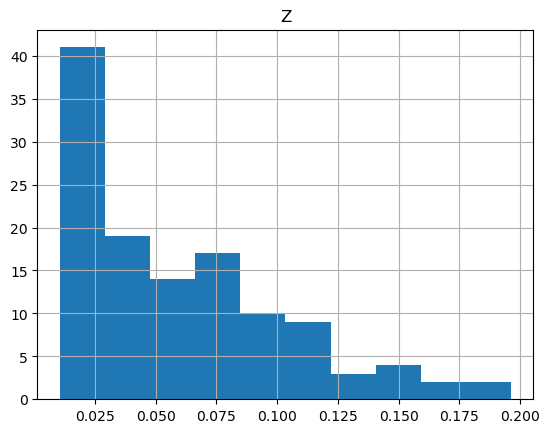

In [158]:
DF.hist('Z')

In [10]:
#Numero de galaxias con datos completos

DF = pd.read_csv(HOME+'/SPS/HIIGs_aladin.csv')

HIIG_names = np.array(DF['Name'])

print('Name | FUV | NUV | u | g | r | i | z | W1 | W2 | W3 | W4 | ALL |')

sep = ' | '

name_id = 0

Found = 0

for name in HIIG_names:
    result_table = Ned.get_table(name, table='photometry')
    filters = np.unique(result_table['Observed Passband'])

    c = 0 

    tab = str(name_id) + '_id' + sep

    #FUV
    if 'FUV (GALEX) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #NUV
    if 'NUV (GALEX) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #u
    if 'u (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #g
    if 'g (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #r
    if 'r (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #i
    if 'i (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #z
    if 'z (SDSS Model) AB' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W1
    if 'W1 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W2
    if 'W2 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W3
    if 'W3 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    #W4
    if 'W4 (WISE)' in filters:
        tab += str(1) + sep
        c += 1
    else:
        tab += str(0) + sep
    


    if c == 11:
        tab += '  All found' + sep
        Found += 1
    else:
        tab += str(0) + sep


    print(tab)

    name_id += 1

print(f'\n Found complete:{Found}')    
    


Name | FUV | NUV | u | g | r | i | z | W1 | W2 | W3 | W4 | ALL |
0_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
1_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
2_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
3_id | 0 | 0 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 0 | 
4_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
5_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
6_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
7_id | 0 | 0 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 0 | 
8_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 0 | 0 | 0 | 0 | 0 | 
9_id | 0 | 0 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 0 | 
10_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
11_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
12_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All found | 
13_id | 0 | 0 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 0 | 
14_id | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 |   All

In [11]:
vega_to_jy(14.442,0.062,'W1')

(0.0005175076549690697, 2.955181421368373e-05)

In [15]:
Irsa.list_catalogs(filter='galex')

{'galex_emphot_v3': 'GALEX/COSMOS Prior-based Photometry Catalog June 2008'}

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from astropy.io import fits as fits
from astropy.table import Table

import os
HOME = os.path.expanduser("~") + '/gdrive/DataHII/'


CIGALE_res = Table.read(HOME + "/HIIGs/CIGALE/out/results.fits")


#sns.pairplot(res[['Mstar', 'SFR', 'Av', 'age_mass']])
#plt.show()

CIGALE_res

id,bayes.attenuation.E_BV_factor,bayes.attenuation.E_BV_factor_err,bayes.attenuation.E_BV_lines,bayes.attenuation.E_BV_lines_err,bayes.attenuation.E_BVs,bayes.attenuation.E_BVs_err,bayes.attenuation.galex.FUV,bayes.attenuation.galex.FUV_err,bayes.attenuation.generic.bessell.B,bayes.attenuation.generic.bessell.B_err,bayes.attenuation.generic.bessell.V,bayes.attenuation.generic.bessell.V_err,bayes.attenuation.powerlaw_slope,bayes.attenuation.powerlaw_slope_err,bayes.attenuation.uv_bump_amplitude,bayes.attenuation.uv_bump_amplitude_err,bayes.attenuation.uv_bump_wavelength,bayes.attenuation.uv_bump_wavelength_err,bayes.attenuation.uv_bump_width,bayes.attenuation.uv_bump_width_err,bayes.dust.alpha,bayes.dust.alpha_err,bayes.dust.gamma,bayes.dust.gamma_err,bayes.dust.qpah,bayes.dust.qpah_err,bayes.dust.umean,bayes.dust.umean_err,bayes.dust.umin,bayes.dust.umin_err,bayes.nebular.f_dust,bayes.nebular.f_dust_err,bayes.nebular.f_esc,bayes.nebular.f_esc_err,bayes.nebular.lines_width,bayes.nebular.lines_width_err,bayes.nebular.logU,bayes.nebular.logU_err,bayes.nebular.ne,bayes.nebular.ne_err,bayes.nebular.zgas,bayes.nebular.zgas_err,bayes.sfh.age,bayes.sfh.age_err,bayes.sfh.age_burst,bayes.sfh.age_burst_err,bayes.sfh.age_main,bayes.sfh.age_main_err,bayes.sfh.f_burst,bayes.sfh.f_burst_err,bayes.sfh.tau_burst,bayes.sfh.tau_burst_err,bayes.sfh.tau_main,bayes.sfh.tau_main_err,bayes.stellar.age_m_star,bayes.stellar.age_m_star_err,bayes.stellar.imf,bayes.stellar.imf_err,bayes.stellar.metallicity,bayes.stellar.metallicity_err,bayes.stellar.old_young_separation_age,bayes.stellar.old_young_separation_age_err,bayes.universe.age,bayes.universe.age_err,bayes.universe.luminosity_distance,bayes.universe.luminosity_distance_err,bayes.universe.redshift,bayes.universe.redshift_err,bayes.dust.luminosity,bayes.dust.luminosity_err,bayes.dust.mass,bayes.dust.mass_err,bayes.sfh.integrated,bayes.sfh.integrated_err,bayes.sfh.sfr,bayes.sfh.sfr_err,bayes.sfh.sfr100Myrs,bayes.sfh.sfr100Myrs_err,bayes.sfh.sfr10Myrs,bayes.sfh.sfr10Myrs_err,bayes.stellar.lum,bayes.stellar.lum_err,bayes.stellar.lum_ly,bayes.stellar.lum_ly_err,bayes.stellar.lum_ly_old,bayes.stellar.lum_ly_old_err,bayes.stellar.lum_ly_young,bayes.stellar.lum_ly_young_err,bayes.stellar.lum_old,bayes.stellar.lum_old_err,bayes.stellar.lum_young,bayes.stellar.lum_young_err,bayes.stellar.m_gas,bayes.stellar.m_gas_err,bayes.stellar.m_gas_old,bayes.stellar.m_gas_old_err,bayes.stellar.m_gas_young,bayes.stellar.m_gas_young_err,bayes.stellar.m_star,bayes.stellar.m_star_err,bayes.stellar.m_star_old,bayes.stellar.m_star_old_err,bayes.stellar.m_star_young,bayes.stellar.m_star_young_err,bayes.stellar.n_ly,bayes.stellar.n_ly_err,bayes.stellar.n_ly_old,bayes.stellar.n_ly_old_err,bayes.stellar.n_ly_young,bayes.stellar.n_ly_young_err,bayes.galex.FUV,bayes.galex.FUV_err,bayes.galex.NUV,bayes.galex.NUV_err,bayes.sloan.sdss.g,bayes.sloan.sdss.g_err,bayes.sloan.sdss.i,bayes.sloan.sdss.i_err,bayes.sloan.sdss.r,bayes.sloan.sdss.r_err,bayes.sloan.sdss.u,bayes.sloan.sdss.u_err,bayes.sloan.sdss.z,bayes.sloan.sdss.z_err,bayes.wise.W1,bayes.wise.W1_err,bayes.wise.W2,bayes.wise.W2_err,bayes.wise.W3,bayes.wise.W3_err,bayes.wise.W4,bayes.wise.W4_err,best.chi_square,best.reduced_chi_square,best.attenuation.E_BV_factor,best.attenuation.E_BV_lines,best.attenuation.E_BVs,best.attenuation.galex.FUV,best.attenuation.generic.bessell.B,best.attenuation.generic.bessell.V,best.attenuation.powerlaw_slope,best.attenuation.uv_bump_amplitude,best.attenuation.uv_bump_wavelength,best.attenuation.uv_bump_width,best.dust.alpha,best.dust.gamma,best.dust.qpah,best.dust.umean,best.dust.umin,best.nebular.f_dust,best.nebular.f_esc,best.nebular.lines_width,best.nebular.logU,best.nebular.ne,best.nebular.zgas,best.sfh.age,best.sfh.age_burst,best.sfh.age_main,best.sfh.f_burst,best.sfh.tau_burst,best.sfh.tau_main,best.stellar.age_m_star,best.stellar.imf,best.stellar.metallicity,best.stellar.old_young_separation_age,best.universe.age,best.universe.luminosity_dista

In [15]:
CIGALE_obs = Table.read(HOME + "/HIIGs/CIGALE/out/observations.fits")

CIGALE_obs

id,redshift,galex.FUV,galex.FUV_err,galex.NUV,galex.NUV_err,sloan.sdss.u,sloan.sdss.u_err,sloan.sdss.g,sloan.sdss.g_err,sloan.sdss.r,sloan.sdss.r_err,sloan.sdss.i,sloan.sdss.i_err,sloan.sdss.z,sloan.sdss.z_err,wise.W1,wise.W1_err,wise.W2,wise.W2_err,wise.W3,wise.W3_err,wise.W4,wise.W4_err
bytes13,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0_UM199,0.12682357755555893,0.05372791656065097,0.005565271937850339,0.06864991439230915,0.006952422159519366,0.08271799518641329,0.008690969996462378,0.13753080974214546,0.013800250581523945,0.10934526967309194,0.011025055058204395,0.18297847342954138,0.01842854259891779,0.12682357755555893,0.014269924068516876,0.0946927606943421,0.011459510800361112,0.10631396008124065,0.01591872350312788,1.387723402858043,0.21845448024003034,10.326712750521486,1.5604611765314553
1_UM282,0.1752265861885708,0.10543868963912581,0.010750948627459882,0.10150326215166904,0.010231554250966984,0.1234809607858603,0.012841556772784302,0.23463889244641323,0.02352749743982336,0.15718098282039206,0.015813809667329082,0.1806342083169977,0.018258505192860132,0.1752265861885708,0.020590455033386128,0.07704008943011295,0.009827988883913234,0.06231466942423622,0.016224243333043134,0.5038519136686446,0.23970785929381982,4.425497469805352,1.4820025679738627
2_UM336,0.30732649292042896,0.06582032160924937,0.006735439132931012,0.07492038492127504,0.007570223828995817,0.11662724050819641,0.012356407375623811,0.27694912668096805,0.02776999073346673,0.2970297844017863,0.029804852182620023,0.2951209226666381,0.0297564259611356,0.30732649292042896,0.03265518605403267,0.13788492215242285,0.015288331222978272,0.10041308160272668,0.01595024464206911,--,--,--,--
4_SBS0934+546,0.35809643710263583,0.22033322944815456,0.022245137056391532,0.24017068680276596,0.02410120622872745,0.2613364576189026,0.02629277999006872,0.35448674447379985,0.035486243591166595,0.3407218616593577,0.034124172916417304,0.5238416190277907,0.052464088748117414,0.35809643710263583,0.036604309966844106,0.3677195993490587,0.037975074576199724,0.37965602420946465,0.03978360221670618,3.30143622586035,0.3539842924561077,22.323490240089914,2.484122555201243
5_UM570,0.04608928809808951,0.07694138506153358,0.012375431209579547,0.07753182378131188,0.00995001743225929,0.0743361389655177,0.00769421175665759,0.20026266903409007,0.020056822633983905,0.10626738654024653,0.010681138359568607,0.05628594992827295,0.005787732169928894,0.04608928809808951,0.0065912435546768245,0.04667848781013259,0.006463791324220405,0.08020294128220173,0.013028985891578663,1.5118298376779267,0.19997121035111262,7.385197207200435,1.1520986345195823
6_UM162,0.21281390459827157,0.053289298103836466,0.005491957948920305,0.0666131544415393,0.006722424631939564,0.09826525828295317,0.010472184367954187,0.22304885593776094,0.022399292387137996,0.1839924489796672,0.018551574168314305,0.2857590543374944,0.028812488339644976,0.21281390459827157,0.023596267173847076,0.10081305560870478,0.012045493425624073,0.14079599310661478,0.019141543806498733,1.5729065189617935,0.2280690308523166,8.10516941205119,1.352266456050775
10_SHOC391,1.2280046179887882,1.0020283291640621,0.1059535350098741,1.076564364305983,0.10959808006654835,1.32678331072416,0.1328807693679271,3.03109815358405,0.30322550141154075,1.893215275777464,0.1893937847571228,1.1428783347897724,0.11436536781222552,1.2280046179887882,0.12313336124539029,3.4794994986662005,0.35567144763898234,8.460388289805882,0.8602730442488944,112.90233200142849,11.3974713087949,375.28576960107836,37.93388437832797
11_WAS69,0.7131813866797402,0.19778802779423982,0.025392074539711533,0.258249803654048,0.027807871559574808,0.4145720317867252,0.04175331778053906,0.8309980410444329,0.08315618007822954,0.7899507213358176,0.07907879253412382,0.6332861644521969,0.06339573325379229,0.7131813866797402,0.07208837226053759,0.35671122689832874,0.03

In [31]:
exal1 = Table.read(HOME + "/HIIGs/CIGALE/out/0_UM199_best_model.fits")

exalx1 = exal1[exal1['Fnu']>= 0.00001]

exalx1

wavelength,Fnu,L_lambda_total,stellar.old,stellar.young,nebular.absorption_old,nebular.absorption_young,nebular.emission_old,nebular.emission_young,attenuation.stellar.old,attenuation.stellar.young,attenuation.nebular.emission_old,attenuation.nebular.emission_young,dust.Umin_Umin,dust.Umin_Umax,igm
nm,mJy,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm,W / nm
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
103.10435734633363,0.0038536883258296073,4.903251035635712e+33,1.2405558973851687e+33,4.065016186943901e+34,0.0,0.0,0.0,0.0,-1.095073741747707e+33,-3.5883046426883834e+34,-0.0,-0.0,0.0,0.0,-9.346562556926029e+30
104.2311809238892,0.008715855289436397,1.0851162693832933e+34,8.08575471381e+33,8.203766220880441e+34,0.0,0.0,7.871730887938366e+23,1.2216340461137203e+26,-7.110567299790818e+33,-7.214345956561215e+34,-7.843367284825304e+23,-1.2172322260151106e+26,0.0,0.0,-1.8227363821518384e+31
105.35800450144475,0.013786244166389655,1.6798576200126704e+34,1.7499575490295793e+34,1.1826663706525338e+35,0.0,0.0,1.0248028625593006e+24,1.5904177686962665e+26,-1.5331086078844982e+34,-1.036114272662434e+35,-1.0203434194164425e+24,-1.5834970448458468e+26,0.0,0.0,-2.512301103063177e+31
106.48482807900031,0.019368484977455743,2.3103712072286404e+34,3.3537730094671133e+34,1.4833409744472194e+35,0.0,0.0,1.3264391401610482e+24,2.0585348213586355e+26,-2.9271603926449325e+34,-1.2946543898268012e+35,-1.3195592423537474e+24,-2.0478577320185252e+26,0.0,0.0,-3.1072559051836874e+31
107.61165165655586,0.02294107481588312,2.679518424193796e+34,4.548941567480244e+34,1.6012027931860448e+35,0.0,0.0,1.7072268457603494e+24,2.649488999193172e+26,-3.9554599959044734e+34,-1.3923004944831953e+35,-1.696798719942977e+24,-2.6333053240688372e+26,0.0,0.0,-2.9861345733470444e+31
108.73847523411143,0.02654146242747334,3.0361271225937507e+34,5.388534787837818e+34,1.7345026928060635e+35,0.0,0.0,2.185399168369565e+24,3.391576854487832e+26,-4.6680769619689435e+34,-1.5025962306183728e+35,-2.1698518362140807e+24,-3.3674485521388776e+26,0.0,0.0,-3.395325394864696e+31
109.86529881166699,0.012777798551875484,1.4318467401077412e+34,1.0751262075769287e+34,9.39077717961466e+34,0.0,0.0,2.7827635029164346e+24,4.3186418410903526e+26,-9.279292094493605e+33,-8.105073044432707e+34,-2.7599395485046436e+24,-4.283220762583826e+26,0.0,0.0,-1.0543935582732958e+31
110.99212238922254,0.025368629876147096,2.785314760875362e+34,5.181080917384713e+34,1.4715467668893088e+35,0.0,0.0,3.525326458273266e+24,5.4710442803514734e+26,-4.455246279700242e+34,-1.2653929485235445e+35,-3.4923015636605534e+24,-5.419792101888379e+26,0.0,0.0,-2.0580609825742883e+31


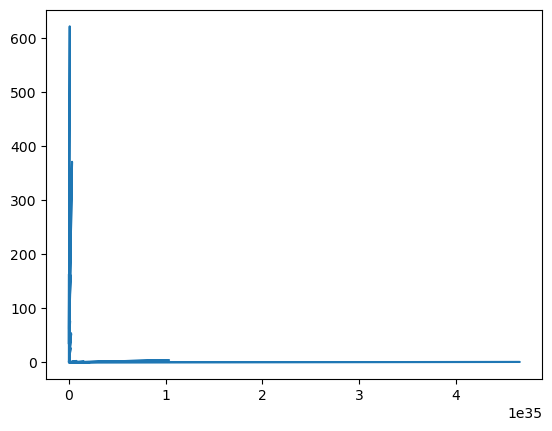

In [32]:
plt.plot(exalx1['L_lambda_total'],exalx1['Fnu'])

In [19]:
exal2 = Table.read(HOME + "/HIIGs/CIGALE/out/11_WAS69_SFH.fits")

exal2

time,SFR
Myr,solMass / yr
int64,float64
0,0.0
1,7.95678657842063
2,15.881777816466398
3,23.77506900483597
4,31.63675518037341
5,39.46693112670221
6,47.26569137485773
7,55.03313020391824


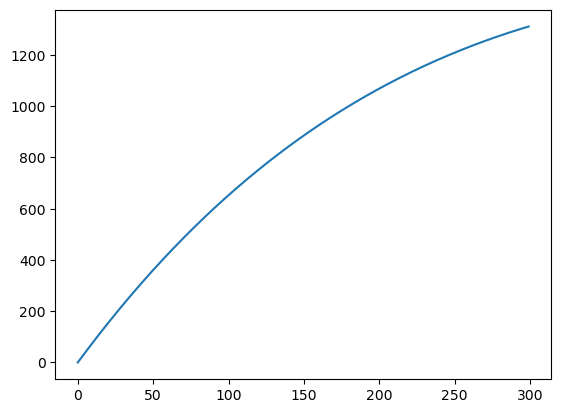

In [20]:
plt.plot(exal2['time'],exal2['SFR'])